# Distillation of GPT-2 Small

## 1. Imports and Configuration

In [1]:
import copy
import os
import math
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import GPT2Config, GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt


def set_seed(seed):
    """Make results reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


CFG = {
    # Data
    "dataset_name": "Salesforce/wikitext",
    "dataset_config": "wikitext-2-raw-v1",  # ~2.4M tokens; the only dataset used in this project
    "block_size": 1024,      # tokens per text block
    "batch_size": 16,        # blocks per training step (~32 GB peak VRAM at block_size 1024)

    # Teacher and student model size
    "teacher_name": "gpt2",
    "student_n_layer": 6,
    "student_n_embd": 384,
    "student_n_head": 6,

    # Training
    "seed": 42,
    "lr": 5e-4,
    "epochs": 50,
    "sweep_epochs": 5,
    "early_stopping_patience": 2,  # stop if validation perplexity does not improve for this many epochs

    # Distillation
    "temperature": 1.0,
    "temperature_values": [1.0, 2.0, 4.0, 7.0, 10.0, 15.0],
    "alpha": 0.5,
}

set_seed(CFG["seed"])

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Record the exact stack: the alpha/T grid in Section 11 was produced on this machine,
# and the published Table 1 numbers came from different hardware.
import transformers
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
if device == "cuda":
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Dual-GPU note (AMD/ROCm):
#   Set HIP_VISIBLE_DEVICES=0,1 to mask the Ryzen integrated GPU, which ROCm otherwise
#   enumerates as a third device that segfaults if compute lands on it.
#   Do NOT also set ROCR_VISIBLE_DEVICES: the two masks compose, and setting both to the
#   same index hides every GPU, silently falling back to CPU.
# The Section 11 grid trains one independent run per card (see experiments/launch_grid.py),
# which measured ~2x throughput vs DataParallel's ~8% on this workload.

Using device: cuda
torch 2.11.0+rocm7.2 | transformers 5.13.0
GPU 0: AMD Radeon PRO W7900
GPU 1: AMD Radeon PRO W7900


## 2. Load the Tokenizer

In [2]:
# Load the GPT-2 tokenizer
# tokenized returns token IDs, attention masks, etc. as a dictionary of lists.
tokenizer = GPT2TokenizerFast.from_pretrained(CFG["teacher_name"])

print("Vocabulary size:", tokenizer.vocab_size)
# Quick sanity check: encode then decode a sentence and confirm we get it back.
demo = tokenizer("This project is a demonstration of knowledge distillation for GPT-2")
print("Token IDs:", demo["input_ids"])
print("Decoded   :", tokenizer.decode(demo["input_ids"]))

Vocabulary size: 50257
Token IDs: [1212, 1628, 318, 257, 13646, 286, 3725, 1233, 40903, 329, 402, 11571, 12, 17]
Decoded   : This project is a demonstration of knowledge distillation for GPT-2


## 3. Load & Prepare the Data

We use **`wikitext-2-raw-v1`** for everything in this project: the temperature sweep, the final
training of all three students, and all evaluation. It is about 2.4M GPT-2 tokens, which is small
enough to train 11 models within a reasonable time budget.

The preparation has three steps:

1. **Tokenize** every line of text into token IDs.
2. **Group into fixed-length blocks** of block_size tokens. Language models train on
   fixed-length sequences, so we concatenate all the tokens into one long stream and then chop
   it into equal chunks. Any leftover tokens that don't fill a full block are dropped.
3. **Create DataLoader** for training, validation and testing

In [ ]:
# 1) Download the raw dataset. It has "train", "validation", and "test" sets.
raw_datasets = load_dataset(CFG["dataset_name"], CFG["dataset_config"])
print(raw_datasets)

# 2) Tokenize text in batches.
def tokenize_batch(batch):
    return tokenizer(batch["text"])

tokenized_datasets = raw_datasets.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)
print(tokenized_datasets)

# 3) Join tokenized text together and split it into fixed-size blocks.
block_size = CFG["block_size"]

def group_texts(batch):
    all_input_ids = []

    for token_list in batch["input_ids"]:
        all_input_ids.extend(token_list)

    total_length = (len(all_input_ids) // block_size) * block_size
    blocks = []

    for i in range(0, total_length, block_size):
        blocks.append(all_input_ids[i:i + block_size])

    return {"input_ids": blocks}

lm_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    remove_columns=tokenized_datasets["train"].column_names,
)
lm_datasets.set_format(type="torch", columns=["input_ids"])

print(lm_datasets)

# 4) Create DataLoaders for each split. Each batch is a tensor with shape (batch_size, block_size).
train_loader = DataLoader(lm_datasets["train"], batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(lm_datasets["validation"], batch_size=CFG["batch_size"])
test_loader = DataLoader(lm_datasets["test"], batch_size=CFG["batch_size"])

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 3760
    })
})
DatasetDict({
    test: Dataset({
        features: ['input_ids'],
        num_rows: 274
    })
    train: Dataset({
        features: ['input_ids'],
        num_rows: 2318
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 240
    })
})


## 4. Load the Teacher (GPT-2 Small)

The teacher is a pretrained GPT-2 small

In [4]:
def count_parameters(model):
    total = 0
    for param in model.parameters():
        total += param.numel()
    return total

# Download/load GPT-2 small.
teacher = GPT2LMHeadModel.from_pretrained(CFG["teacher_name"]).to(device)
teacher.eval()  # freeze behaviour: no dropout, no parameter updates

teacher_params = count_parameters(teacher)
print(f"Teacher: {CFG['teacher_name']}")
print(f"Teacher parameters: {teacher_params}")
print(f"Teacher layers: {teacher.config.n_layer}, hidden size: {teacher.config.n_embd}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Teacher: gpt2
Teacher parameters: 124439808
Teacher layers: 12, hidden size: 768


## 5. Build Three Student Models (Same Architecture)

We create three students with the **same smaller GPT-2 architecture** so the comparison is fair.
Only the training objective changes:

- **Teacher + corpus:** learns from both hard labels and teacher soft labels.
- **Corpus only:** learns only from the true next tokens in WikiText.
- **Teacher only:** learns only by matching the teacher's output distribution.

All three students use the same tokenizer and vocabulary as the teacher, which is required for
comparing next-token distributions.

In [5]:
def build_student():
    student_config = GPT2Config(
        vocab_size=teacher.config.vocab_size,    # MUST match the teacher,number if tokens in the vocabulary
        n_positions=teacher.config.n_positions,  # max context length (1024)
        n_ctx=teacher.config.n_positions,
        n_embd=CFG["student_n_embd"],            # hidden size (width)
        n_layer=CFG["student_n_layer"],          # number of transformer blocks (depth)
        n_head=CFG["student_n_head"],            # attention heads
        bos_token_id=tokenizer.bos_token_id,     # token ID for the beginning-of-sequence token
        eos_token_id=tokenizer.eos_token_id,     # token ID for the end-of-sequence token
    )
    return GPT2LMHeadModel(student_config).to(device)


def build_seeded_student():
    # Build each student from the same initial weights for a fair comparison.
    set_seed(CFG["seed"])
    return build_student()


student_models = {
    "Teacher + corpus": build_seeded_student(),
    "Corpus only": build_seeded_student(),
    "Teacher only": build_seeded_student(),
}

student_params = count_parameters(student_models["Teacher + corpus"]) # all students have the same number of parameters, so we can just count one of them
print(f"Student parameters: {student_params:,}")
print(f"Student layers: {CFG['student_n_layer']}, hidden size: {CFG['student_n_embd']}")
print(f"Compression ratio (teacher / student): {teacher_params / student_params:.1f}x")

Student parameters: 30,339,456
Student layers: 6, hidden size: 384
Compression ratio (teacher / student): 4.1x


## 6. Loss Functions For The Three Training Methods

This project compares three ways to train the same student architecture:

- **Teacher + corpus:** uses both the real corpus labels and the teacher's soft targets.
- **Corpus only:** uses only the real next-token labels from the dataset.
- **Teacher only:** uses only the teacher's soft targets.

In code, the combined method is:

```text
total_loss = alpha * corpus_loss + (1 - alpha) * teacher_loss
```

The loss design follows ideas from Hinton, Vinyals, and Dean's paper **Distilling the Knowledge in a Neural Network**:

**Hard and soft losses**

- `corpus_loss` is the hard-label loss. It uses cross-entropy against the true next token from the dataset.
- `teacher_loss` is the soft-label loss. It uses KL divergence to match the teacher's probability distribution.
- The paper explains that combining hard labels and soft teacher targets can improve the student.

**Temperature**

- Temperature softens the teacher's probability distribution.
- A higher temperature makes the probabilities less sharp and reveals more information about the teacher's uncertainty.
- In this project, we run a temperature sweep before final training to choose a good value.

**T squared scaling**

- The paper notes that gradients from soft targets shrink when temperature increases.
- To compensate, the distillation loss is multiplied by `temperature ** 2`.
- In the code, this scaling is applied inside `teacher_loss`.


In [6]:
def compute_training_loss(student_logits, teacher_logits, input_ids, method):
    # This function computes the loss for one training batch.

    # student_logits: (batch_size, block_size, vocab_size) tensor of scores for every possible next token
    # we extract the vocab_size
    vocab_size = student_logits.size(-1)

    # GPT predicts the next token, so we compare position 0 with label 1, position 1 with label 2, etc.
    # take all batches, take all positions except the last one, take all vocabulary scores
    student_next_token_scores = student_logits[:, :-1, :].contiguous()
    # take all batches, take tokens from position 1 onward
    true_next_tokens = input_ids[:, 1:].contiguous()

    # Corpus loss: student vs. the real next token from the dataset.
    # corpus_loss = average of -log(student probability assigned to each true next token)
    # cross entropy expect raw logits
    corpus_loss = F.cross_entropy(
        student_next_token_scores.view(-1, vocab_size), # reshape [batch_size * (block_size - 1), vocab_size]
        true_next_tokens.view(-1),                      # reshape [batch_size * (block_size - 1)]
    )

    # Teacher loss: student vs. the teacher's full probability distribution.
    teacher_loss = torch.zeros((), device=student_logits.device)
    if teacher_logits is not None: ## no teacher_logits for corpus only training
        teacher_next_token_scores = teacher_logits[:, :-1, :].contiguous()

        student_log_probs = F.log_softmax(student_next_token_scores / CFG["temperature"], dim=-1)
        teacher_probs = F.softmax(teacher_next_token_scores / CFG["temperature"], dim=-1)

        teacher_loss = F.kl_div(
            student_log_probs.view(-1, vocab_size),
            teacher_probs.view(-1, vocab_size),
            reduction="batchmean",
        ) * (CFG["temperature"] ** 2)

    # Choose which training method this student uses.
    if method == "combined":
        total_loss = CFG["alpha"] * corpus_loss + (1 - CFG["alpha"]) * teacher_loss
    elif method == "corpus_only":
        total_loss = corpus_loss
    elif method == "teacher_only":
        total_loss = teacher_loss
    else:
        raise ValueError(f"Unknown training method: {method}")

    return total_loss, corpus_loss, teacher_loss

## 7. Training

### 7.1 Perplexity Evaluation

Perplexity measures how well the model predicts the next token. It is calculated from the average cross-entropy loss:

```text
perplexity = exp(average cross-entropy loss)
```

In [7]:
def evaluate_perplexity(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)

            # Hugging Face computes the cross-entropy internally when labels are provided.
            # outputs.loss is the average negative log probability of the correct next tokens.
            outputs = model(input_ids=input_ids, labels=input_ids)

            num_tokens = input_ids.size(0) * (input_ids.size(1) - 1)
            total_loss = total_loss + outputs.loss.item() * num_tokens
            total_tokens = total_tokens + num_tokens

    average_loss = total_loss / total_tokens  # average log perplexity
    return math.exp(average_loss)  # convert back to perplexity

### 7.2 Model Training

Main model training loop with early stopping.

After every epoch the student is scored on the validation set. If validation perplexity has not
improved for `early_stopping_patience` epochs, training stops.

Early stopping by itself would leave the model sitting on the epoch that *failed* to improve, which
is one or two epochs past its best. We therefore keep a copy of the weights from the best epoch and
restore them before returning, so the model that gets saved, evaluated on the test set, and used for
text generation is the same model that early stopping selected. This also makes the final students
consistent with the temperature sweep, which ranks temperatures by their best epoch.

In [ ]:
def train_model(model, name, method):
    set_seed(CFG["seed"])

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
    loss_history = []
    validation_history = []

    best_validation_ppl = None
    best_epoch = None
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(CFG["epochs"]):
        model.train()
        progress = tqdm(train_loader, desc=f"{name}: epoch {epoch + 1}/{CFG['epochs']}")

        total_epoch_loss = 0
        num_batches = 0

        for batch in progress:
            input_ids = batch["input_ids"].to(device)

            # Run the student, get the final output scores (logits) for every possible next token.
            student_logits = model(input_ids=input_ids).logits

            # Run the teacher only when this method needs teacher guidance.
            teacher_logits = None
            if method in ["combined", "teacher_only"]:
                with torch.no_grad():
                    teacher_logits = teacher(input_ids=input_ids).logits

            loss, corpus_loss, teacher_loss = compute_training_loss(
                student_logits,
                teacher_logits,
                input_ids,
                method,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_epoch_loss = total_epoch_loss + loss.item()
            num_batches = num_batches + 1
            progress.set_postfix(loss=f"{loss.item():.3f}")

        average_epoch_loss = total_epoch_loss / num_batches
        loss_history.append(average_epoch_loss)
        print(f"{name} average training loss after epoch {epoch + 1}: {average_epoch_loss:.3f}")

        validation_ppl = evaluate_perplexity(model, val_loader)
        validation_history.append(validation_ppl)
        print(f"{name} validation perplexity after epoch {epoch + 1}: {validation_ppl:.2f}")

        if best_validation_ppl is None or validation_ppl < best_validation_ppl:
            best_validation_ppl = validation_ppl
            best_epoch = epoch + 1
            # Snapshot the weights, not just the score. Training continues from here, so without a
            # copy these values would be overwritten by the next optimizer step.
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement = epochs_without_improvement + 1

        if epochs_without_improvement >= CFG["early_stopping_patience"]:
            print(f"Early stopping {name}: validation perplexity did not improve.")
            break

    # Early stopping leaves the model on the epoch that failed to improve, which is 1-2 epochs past
    # its best. Roll back so the model we save and evaluate is the one early stopping selected.
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored {name} to epoch {best_epoch} (validation perplexity {best_validation_ppl:.2f})")

    print(f"Finished training {name} model.")
    return loss_history, validation_history

### 7.3 Temperature Sweep Before Final Training
- Before final training, we try several temperature values: 1, 2, 4, 7, 10, 15.
- Each sweep run trains a throwaway student with `method="teacher_only"`, so the teacher's soft targets are the only training signal.
- The sweep uses validation perplexity to choose a good temperature.
- After the sweep, `CFG["temperature"]` is set to the best temperature.
- Fewer epochs are used to save run time, so we expect these perplexities to be higher than the final models.

In [9]:
temperature_values = CFG["temperature_values"]
original_epochs = CFG["epochs"]
sweep_epochs = CFG["sweep_epochs"]

sweep_rows = []

for temperature in temperature_values:
    print(f"\n=== Temperature sweep: T = {temperature} ===")

    CFG["temperature"] = temperature
    CFG["epochs"] = sweep_epochs

    sweep_student = build_seeded_student()
    # Sweep with the teacher signal alone so the corpus loss does not dilute the temperature effect.
    sweep_loss_history, sweep_validation_history = train_model(
        sweep_student,
        name=f"Temperature {temperature}",
        method="teacher_only",
    )

    best_validation_ppl = min(sweep_validation_history)
    final_validation_ppl = sweep_validation_history[-1]

    sweep_rows.append(
        {
            "Temperature": temperature,
            # This loss is KL * T^2, so it grows with T by construction and must not be compared
            # across rows. Use the validation perplexity columns to rank temperatures.
            "Final training loss (KL x T^2)": sweep_loss_history[-1],
            "Best validation perplexity": best_validation_ppl,
            "Final validation perplexity": final_validation_ppl,
        }
    )

    del sweep_student
    if device == "cuda":
        torch.cuda.empty_cache()

# Pick the temperature with the lowest best validation perplexity.
temperature_sweep = pd.DataFrame(sweep_rows)
best_temperature = temperature_sweep.loc[temperature_sweep["Best validation perplexity"].idxmin(), "Temperature"]

# Restore the normal epoch count, but keep the best temperature for final training.
CFG["epochs"] = original_epochs
CFG["temperature"] = float(best_temperature)

print(f"\nBest temperature from sweep: {CFG['temperature']}")
temperature_sweep


=== Temperature sweep: T = 1.0 ===


Temperature 1.0: epoch 1/5:   0%|          | 0/145 [00:00<?, ?it/s]

c:\Users\Ethan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
c:\Users\Ethan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Using AOTriton backend for Efficient Attention backward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention_backward.hip:551.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Temperature 1.0 average training loss after epoch 1: 3.891
Temperature 1.0 validation perplexity after epoch 1: 735.70


Temperature 1.0: epoch 2/5:   0%|          | 0/145 [00:00<?, ?it/s]

...

Temperature 15.0: epoch 4/5:   0%|          | 0/145 [00:00<?, ?it/s]

Temperature 15.0 average training loss after epoch 4: 1.964
Temperature 15.0 validation perplexity after epoch 4: 2528.43


Temperature 15.0: epoch 5/5:   0%|          | 0/145 [00:00<?, ?it/s]

Temperature 15.0 average training loss after epoch 5: 1.873
Temperature 15.0 validation perplexity after epoch 5: 2190.88
Restored Temperature 15.0 to epoch 5 (validation perplexity 2190.88)
Finished training Temperature 15.0 model.

Best temperature from sweep: 1.0


,Temperature,Final training loss (KL x T^2),Best validation perplexity,Final validation perplexity
0,1.0,2.185229,258.123115,258.123115
1,2.0,2.749672,549.957637,549.957637
2,4.0,2.167040,1302.203994,1302.203994
3,7.0,1.900946,1516.869938,1516.869938
4,10.0,1.947665,2164.115828,2164.115828
5,15.0,1.873398,2190.884306,2190.884306


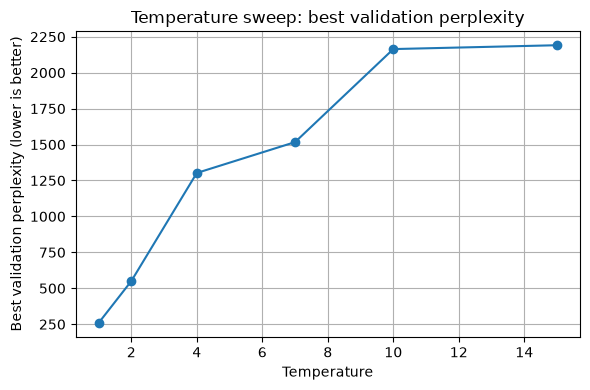

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(
    temperature_sweep["Temperature"],
    temperature_sweep["Best validation perplexity"],
    marker="o",
)
plt.title("Temperature sweep: best validation perplexity")
plt.xlabel("Temperature")
plt.ylabel("Best validation perplexity (lower is better)")
plt.grid(True)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/temperature_sweep.png", dpi=150)
plt.show()

### 7.4 Train All 3 Student Models
- Teacher + corpus
- Corpus only
- Teacher only

In [11]:
# Train all three final student variants using the best temperature from the sweep.
print(f"Final student training will use temperature = {CFG['temperature']}")

training_methods = {
    "Teacher + corpus": "combined",
    "Corpus only": "corpus_only",
    "Teacher only": "teacher_only",
}

student_loss_history = {}
student_validation_history = {}

for name, method in training_methods.items():
    print(f"\n=== Training: {name} ===")
    loss_history, validation_history = train_model(student_models[name], name, method)
    student_loss_history[name] = loss_history
    student_validation_history[name] = validation_history

Final student training will use temperature = 1.0

=== Training: Teacher + corpus ===


Teacher + corpus: epoch 1/50:   0%|          | 0/145 [00:00<?, ?it/s]

Teacher + corpus average training loss after epoch 1: 5.804
Teacher + corpus validation perplexity after epoch 1: 1008.77


Teacher + corpus: epoch 2/50:   0%|          | 0/145 [00:00<?, ?it/s]

Teacher + corpus average training loss after epoch 2: 4.992
Teacher + corpus validation perplexity after epoch 2: 579.92


...

Teacher only average training loss after epoch 39: 0.658
Teacher only validation perplexity after epoch 39: 89.44


Teacher only: epoch 40/50:   0%|          | 0/145 [00:00<?, ?it/s]

Teacher only average training loss after epoch 40: 0.649
Teacher only validation perplexity after epoch 40: 90.00


Teacher only: epoch 41/50:   0%|          | 0/145 [00:00<?, ?it/s]

Teacher only average training loss after epoch 41: 0.644
Teacher only validation perplexity after epoch 41: 90.01
Early stopping Teacher only: validation perplexity did not improve.
Restored Teacher only to epoch 39 (validation perplexity 89.44)
Finished training Teacher only model.


## 8. Save The Trained Student Models

We save each trained student separately so the three methods can be reloaded or inspected later.

In [12]:
checkpoint_dirs = {
    "Teacher + corpus": "checkpoints/student_teacher_plus_corpus",
    "Corpus only": "checkpoints/student_corpus_only",
    "Teacher only": "checkpoints/student_teacher_only",
}

for name, path in checkpoint_dirs.items():
    os.makedirs(path, exist_ok=True)
    student_models[name].save_pretrained(path)
    tokenizer.save_pretrained(path)
    print(f"Saved {name} -> {path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Teacher + corpus -> checkpoints/student_teacher_plus_corpus


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Corpus only -> checkpoints/student_corpus_only


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Teacher only -> checkpoints/student_teacher_only


## 9. Evaluation & Analysis

We now compare the **teacher** and all **three student training methods**.

### 9.1 Validation and test perplexity
Lower is better. Validation perplexity helps check overfitting, while test perplexity is the final performance number.

In [13]:
# Measure validation and test perplexity.
teacher_val_ppl = evaluate_perplexity(teacher, val_loader)
teacher_ppl = evaluate_perplexity(teacher, test_loader)

student_val_ppls = {}
student_ppls = {}

for name, model in student_models.items():
    student_val_ppls[name] = evaluate_perplexity(model, val_loader)
    student_ppls[name] = evaluate_perplexity(model, test_loader)

print(f"Teacher validation perplexity: {teacher_val_ppl:.2f}")
print(f"Teacher test perplexity: {teacher_ppl:.2f}")

for name in student_models:
    print(f"{name} validation perplexity: {student_val_ppls[name]:.2f}")
    print(f"{name} test perplexity: {student_ppls[name]:.2f}")

Teacher validation perplexity: 30.63
Teacher test perplexity: 29.37
Teacher + corpus validation perplexity: 111.18
Teacher + corpus test perplexity: 115.64
Corpus only validation perplexity: 214.45
Corpus only test perplexity: 227.19
Teacher only validation perplexity: 89.44
Teacher only test perplexity: 90.72


### 9.2 Generated text quality
We feed the **same prompts** with deterministic decoding to the teacher and each student, then compare fluency, coherence, and repetition.

In [14]:
def generate_text(model, prompt, max_new_tokens=40):
    model.eval()
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # deterministic generation for fair comparison
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

all_models = {"Teacher (GPT-2)": teacher, **student_models}

prompts = [
    "The history of artificial intelligence",
    "The city was famous for its",
    "Climate change is one of the most important",
    "A good machine learning model should",
    "The scientist opened the notebook and discovered",
    "In simple terms, gravity is",
    "The main advantage of renewable energy is",
    "During the experiment, the researchers observed",
    "Once upon a time in a small village",
]

for prompt in prompts:
    print("=" * 90)
    print(f"PROMPT: {prompt}\n")
    for name, model in all_models.items():
        print(f"[{name}] {generate_text(model, prompt)}\n")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: The history of artificial intelligence

[Teacher (GPT-2)] The history of artificial intelligence is littered with examples of how it has been used to create a world where people are more likely to be able to do things that are not possible in the real world.

The problem is that

[Teacher + corpus] The history of artificial intelligence, the world was a very popularized by the world . The first game was the first game to be played by the game in the series . The game was the first game in the series of the

[Corpus only] The history of artificial intelligence , and the main history of the Dominican Republic of the Dominican Republic of the Dominican Republic of the Dominican Republic . The Dominican Republic of the Dominican Republic of the Dominican Republic of the Dominican Republic of the Dominican

[Teacher only] The history of artificial intelligence, and the world is not a human being, but it is a human being, and it is a human being a human being, and a human being, and 

### 9.3 Inference speed
We time how long each model takes to generate a fixed number of tokens and report **tokens per
second**. Higher is better.

In [15]:
def measure_speed(model, n_tokens=100, n_runs=5):
    model.eval()
    input_ids = tokenizer("The", return_tensors="pt").input_ids.to(device)

    def one_run():
        with torch.no_grad():
            model.generate(
                input_ids,
                max_new_tokens=n_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

    # The first generation call is often slower than normal because PyTorch/GPU may need to do one-time setup
    one_run()
    if device == "cuda":
        torch.cuda.synchronize() # forces Python to wait until the GPU is done

    start = time.time()
    for _ in range(n_runs):
        one_run()
    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start
    return (n_tokens * n_runs) / elapsed


teacher_tps = measure_speed(teacher)
student_tps = {
    name: measure_speed(model)
    for name, model in student_models.items()
}

print(f"Teacher: {teacher_tps:.1f} tokens/sec")
for name, tps in student_tps.items():
    print(f"{name}: {tps:.1f} tokens/sec ({tps / teacher_tps:.1f}x teacher speed)")

Teacher: 164.6 tokens/sec
Teacher + corpus: 295.1 tokens/sec (1.8x teacher speed)
Corpus only: 294.3 tokens/sec (1.8x teacher speed)
Teacher only: 292.3 tokens/sec (1.8x teacher speed)


### 9.4 Model size & parameter count
Finally we report parameter counts, on-disk size, perplexity, and speed in one summary table.

In [16]:
def dir_size_mb(path) -> float:
    """Total size (in MB) of the saved-model files in a folder."""
    total_bytes = 0
    for root, _dirs, files in os.walk(path):
        for f in files:
            total_bytes += os.path.getsize(os.path.join(root, f))
    return total_bytes / (1024 ** 2)


teacher_size_mb = teacher_params * 4 / (1024 ** 2)  # teacher model is not saved, so estimate: float32 weights

rows = [
    {
        "Model": "Teacher (GPT-2)",
        "Training method": "pretrained teacher",
        "Parameters (M)": teacher_params / 1e6,
        "Disk size (MB)": teacher_size_mb,
        "Validation perplexity": teacher_val_ppl,
        "Test perplexity": teacher_ppl,
        "Tokens/sec": teacher_tps,
    }
]

for name in student_models:
    rows.append(
        {
            "Model": f"Student ({name})",
            "Training method": training_methods[name],
            "Parameters (M)": student_params / 1e6,
            "Disk size (MB)": dir_size_mb(checkpoint_dirs[name]),
            "Validation perplexity": student_val_ppls[name],
            "Test perplexity": student_ppls[name],
            "Tokens/sec": student_tps[name],
        }
    )

summary = pd.DataFrame(rows).round(2)
display(summary)

,Model,Training method,Parameters (M),Disk size (MB),Validation perplexity,Test perplexity,Tokens/sec
0,Teacher (GPT-2),pretrained teacher,124.44,474.70,30.63,29.37,164.57
1,Student (Teacher + corpus),combined,30.34,119.14,111.18,115.64,295.09
2,Student (Corpus only),corpus_only,30.34,119.14,214.45,227.19,294.31
3,Student (Teacher only),teacher_only,30.34,119.14,89.44,90.72,292.31


## 10. Plots & Conclusions

Visualising the numbers makes the training-method comparison clearer. We plot:

1. Training loss per epoch for all three students.
2. Validation perplexity per epoch for all three students.
3. Final test perplexity for teacher and students.
4. Inference speed for teacher and students.

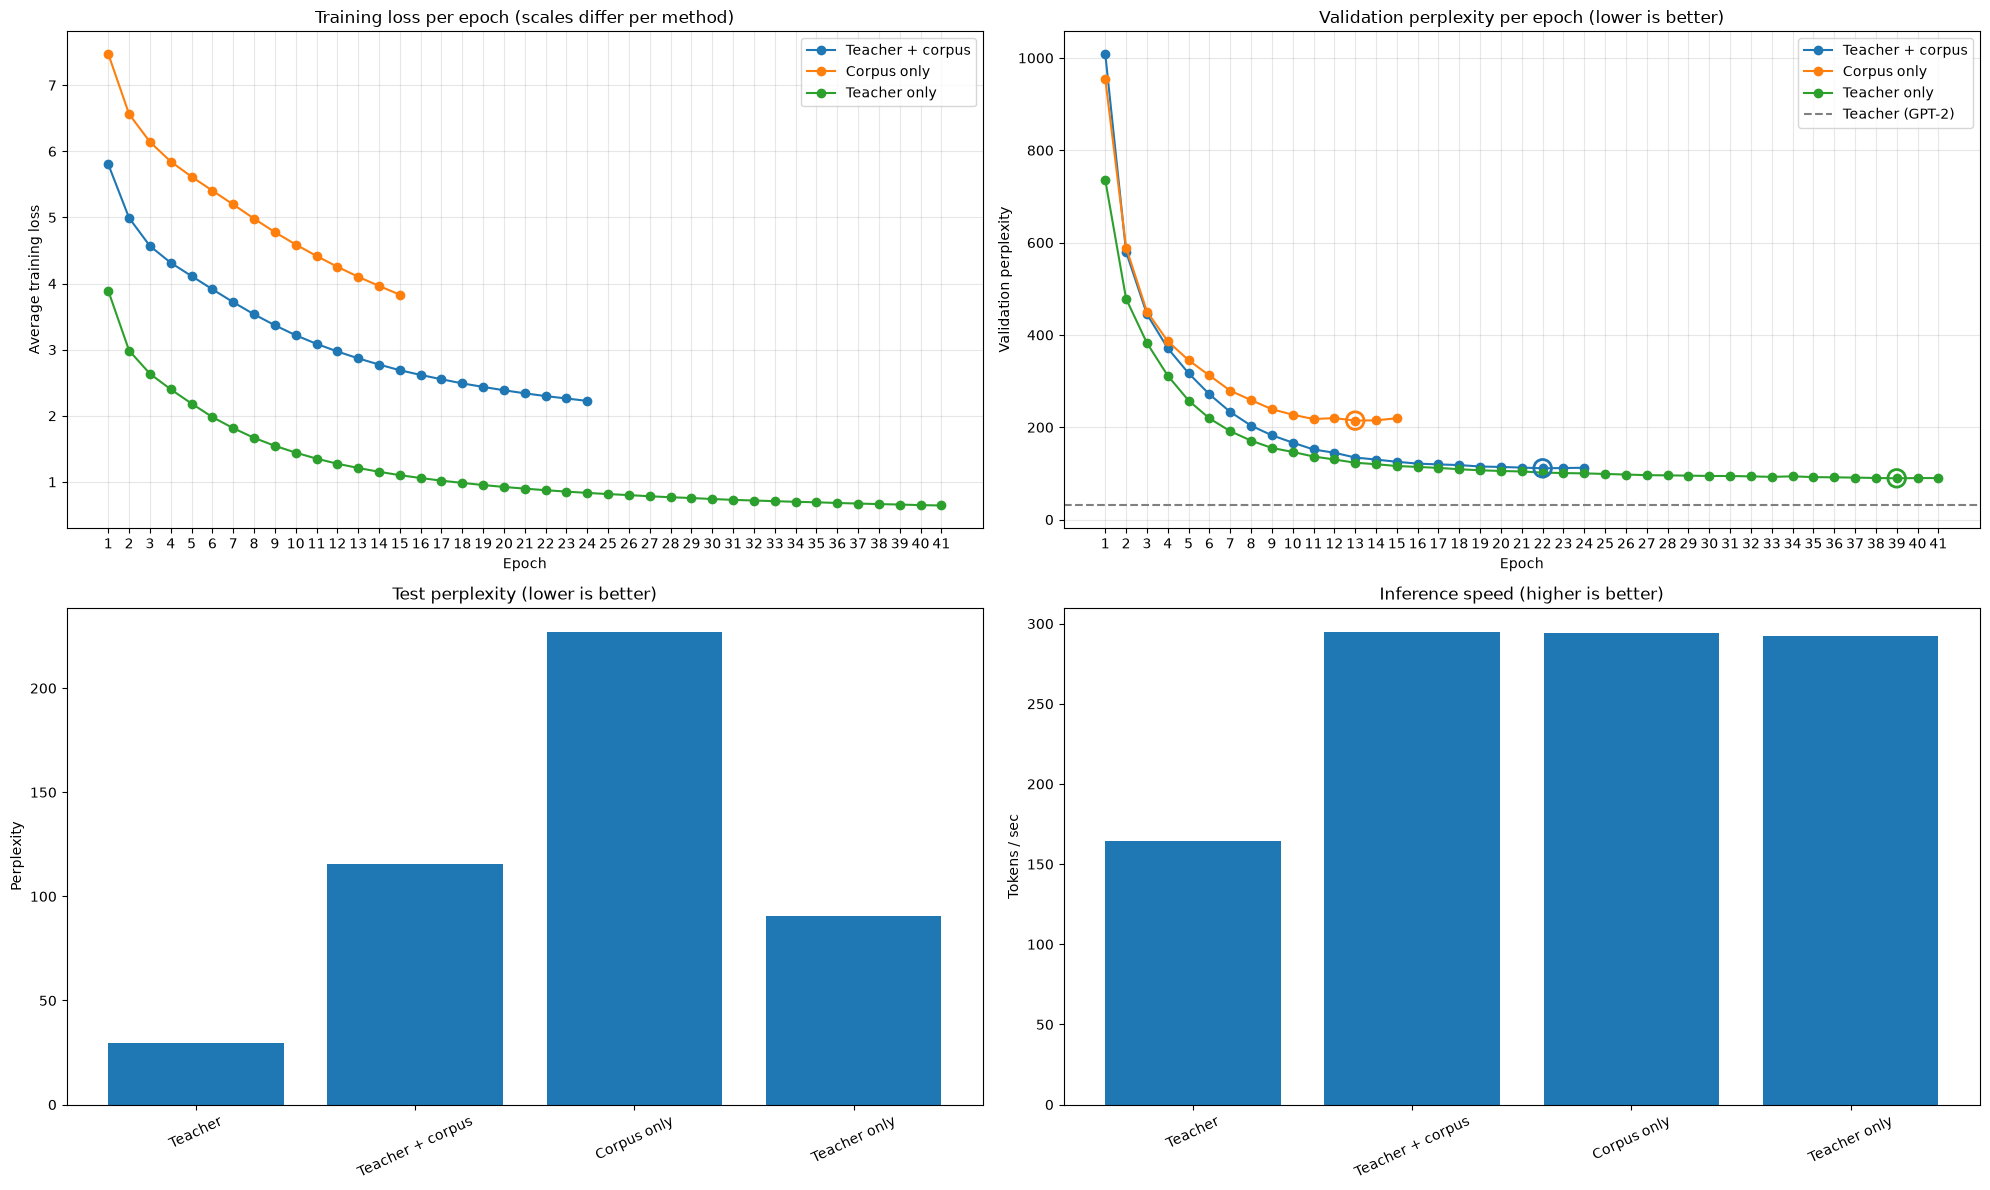

In [21]:
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

max_epochs_plotted = max(len(losses) for losses in student_loss_history.values())

# (1) Training loss per epoch. The three curves use different loss definitions, so they show each
# student's own progress but must not be compared with each other.
for name, losses in student_loss_history.items():
    epochs_axis = range(1, len(losses) + 1)
    axes[0].plot(epochs_axis, losses, marker="o", label=name)
axes[0].set_title("Training loss per epoch (scales differ per method)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average training loss")
axes[0].set_xticks(range(1, max_epochs_plotted + 1))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# (2) Validation perplexity per epoch, on a raw (linear) scale. Measured identically for every
# method, so this is the curve to compare across students.
for name, ppls in student_validation_history.items():
    epochs_axis = range(1, len(ppls) + 1)
    line, = axes[1].plot(epochs_axis, ppls, marker="o", label=name)
    best_epoch = int(np.argmin(ppls)) + 1
    axes[1].scatter(
        [best_epoch], [min(ppls)],
        s=160, facecolors="none", edgecolors=line.get_color(), linewidths=2, zorder=5,
    )
axes[1].axhline(teacher_val_ppl, color="gray", linestyle="--", linewidth=1.5, label="Teacher (GPT-2)")
axes[1].set_title("Validation perplexity per epoch (lower is better)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation perplexity")
axes[1].set_xticks(range(1, max_epochs_plotted + 1))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# (3) Final test perplexity.
plot_names = ["Teacher"] + list(student_models.keys())
plot_ppl = [teacher_ppl] + [student_ppls[name] for name in student_models]
axes[2].bar(plot_names, plot_ppl)
axes[2].set_title("Test perplexity (lower is better)")
axes[2].set_ylabel("Perplexity")
axes[2].tick_params(axis="x", rotation=25)

# (4) Inference speed.
plot_tps = [teacher_tps] + [student_tps[name] for name in student_models]
axes[3].bar(plot_names, plot_tps)
axes[3].set_title("Inference speed (higher is better)")
axes[3].set_ylabel("Tokens / sec")
axes[3].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("results/comparison.png", dpi=150)
plt.show()

## 11. The $\alpha$ and Temperature Grid

Sections 1-10 fix $\alpha=0.5$ and choose $T$ from a short 5-epoch sweep. This section
answers two follow-up questions directly:

1. **What does $\alpha$ do?** Since $\alpha$ weights the corpus (cross-entropy) term in
   $\mathcal{L}=\alpha\,\mathrm{CE}+(1-\alpha)\,\mathcal{L}_{\mathrm{KD}}$, the three original
   students are already the endpoints and midpoint: $\alpha=1$ is corpus only, $\alpha=0$
   is teacher only, $\alpha=0.5$ is the combined loss. We fill in $\alpha\in\{0.25, 0.75\}$
   to get a five-point curve.
2. **What happens below $T=1$?** The original sweep only tested $T\ge 1$. We add $T=0.5$
   (a *sharpened* teacher) and re-test $T=2$ under **full** training rather than 5 epochs.

Every point here is trained to early stopping with the same recipe, seed, and hardware, so
the curves are internally consistent.

### Why these runs live outside the notebook

Eight full training runs take several GPU-hours, which is impractical to hold in a single
notebook kernel session. They are executed by `experiments/launch_grid.py`, which pins one
independent process per GPU, and each writes a JSON record to `results/runs/`. The cells
below **load those results** and do the analysis -- no retraining.

The training code itself is not duplicated: `experiments/kd_core.py` is the same data
pipeline, loss, and training loop as Sections 3-7, with $\alpha$ and $T$ as explicit
arguments instead of globals. `experiments/verify_core.py` checks it reproduces this
notebook's loss **bit-for-bit** at $\alpha\in\{0,0.5,1\}$ and $T\in\{0.5,1,2,4\}$.

### 11.1 Is the $T=0.5$ result confounded by the $T^2$ factor?

Section 4 argues the $T^2$ factor "keeps the teacher signal at a similar strength at every
temperature." That derivation is a **large-$T$** approximation, so before trusting any $T<1$
result we checked whether it still holds. Probing a CE-trained student gave:

| $T$ | $\|\nabla_{\theta}\mathcal{L}_{\mathrm{KD}}\|$ | ratio to $\|\nabla_{\theta}\mathrm{CE}\|$ |
|---|---:|---:|
| 0.5 | 2.784 | **3.54$\times$** |
| 1.0 | 0.739 | 0.94 |
| 2.0 | 0.394 | 0.50 |
| 4.0 | 0.167 | 0.21 |

On that probe the $T=0.5$ gradient is about $3.8\times$ the $T=1$ value, which would mean a
naive $T=0.5$ run changes two things at once: it sharpens the target *and* raises the
effective learning rate on the KD term. That would make any perplexity difference
uninterpretable, so we treated it as a threat to validity and tested it.

We therefore run $T=0.5$ **twice**:

- `a0.50_T0.5` — the standard Hinton convention, directly comparable to the other $T$ values;
- `a0.50_T0.5_gm` — a **gradient-matched control**, where the KD term carries an extra scalar
  $c=\|\nabla\mathcal{L}_{\mathrm{KD}}(T{=}1)\|/\|\nabla\mathcal{L}_{\mathrm{KD}}(T{=}0.5)\|$
  recalibrated each epoch on a fixed probe batch.

**The control refutes the hypothesis, which is the useful outcome.** The two runs land 2.0
perplexity apart (153.95 grad-matched vs 155.96 standard) — negligible beside the ~43-point
penalty of using $T=0.5$ at all. And the correction actually needed during training was not the
$c\approx0.26$ the static probe implied: it averaged $c=1.18$ and exceeded 1 in 78% of epochs
(range 0.77–1.48, plotted in 11.3). Once the student is genuinely being trained to match the
teacher, its distribution tracks the teacher's closely enough that the $T<1$ gradient mismatch
largely disappears, so the $T^2$ factor behaves better in practice than the asymptotic argument
predicts.

The payoff is that the $T=0.5$ result in 11.3 can be read at face value: it reflects the
sharpened target itself, not an accident of gradient scale.

In [2]:
# Load the completed grid runs. Training happens in experiments/launch_grid.py; this only reads.
import sys
sys.path.insert(0, "experiments")

from analyze_grid import (
    load_runs, summary_table, plot_alpha_sweep, plot_temperature_grid, PUBLISHED,
)

grid = load_runs()
print(f"Loaded {len(grid)} runs from results/runs/\n")
display(summary_table(grid))

Loaded 8 runs from results/runs/



,Tag,Alpha,T,Grad-matched,Best ep.,Epochs run,Best val PPL,Test PPL,Val PPL @15ep,Wall (min)
0,a0.50_T0.5,0.50,0.5,False,19,21,148.26,155.96,153.75,51.08
1,a0.00_T1,0.00,1.0,False,50,50,87.10,88.06,113.92,115.02
2,a0.25_T1,0.25,1.0,False,43,45,83.22,85.59,104.84,109.19
3,a0.50_T1,0.50,1.0,False,22,24,108.21,112.60,114.93,58.31
4,a0.75_T1,0.75,1.0,False,17,19,145.62,152.44,145.66,46.16
5,a1.00_T1,1.00,1.0,False,14,16,217.50,226.90,217.50,16.49
6,a0.50_T2,0.50,2.0,False,21,23,107.43,110.90,119.59,55.77
7,a0.50_T0.5_gm,0.50,0.5,True,21,23,147.89,153.95,158.85,56.02


### 11.2 Effect of $\alpha$ at $T=1$

$\alpha$ interpolates between pure distillation ($\alpha=0$) and ordinary language-model
training ($\alpha=1$).

**A caveat to read the curve honestly.** With `early_stopping_patience = 2`, different
$\alpha$ values stop at different epochs, so a raw "best PPL vs $\alpha$" curve is partly an
*epochs-trained* curve. The left panel therefore also plots the best validation perplexity
**within a fixed 15-epoch budget** (dotted), and the right panel shows the stopping epoch
explicitly.

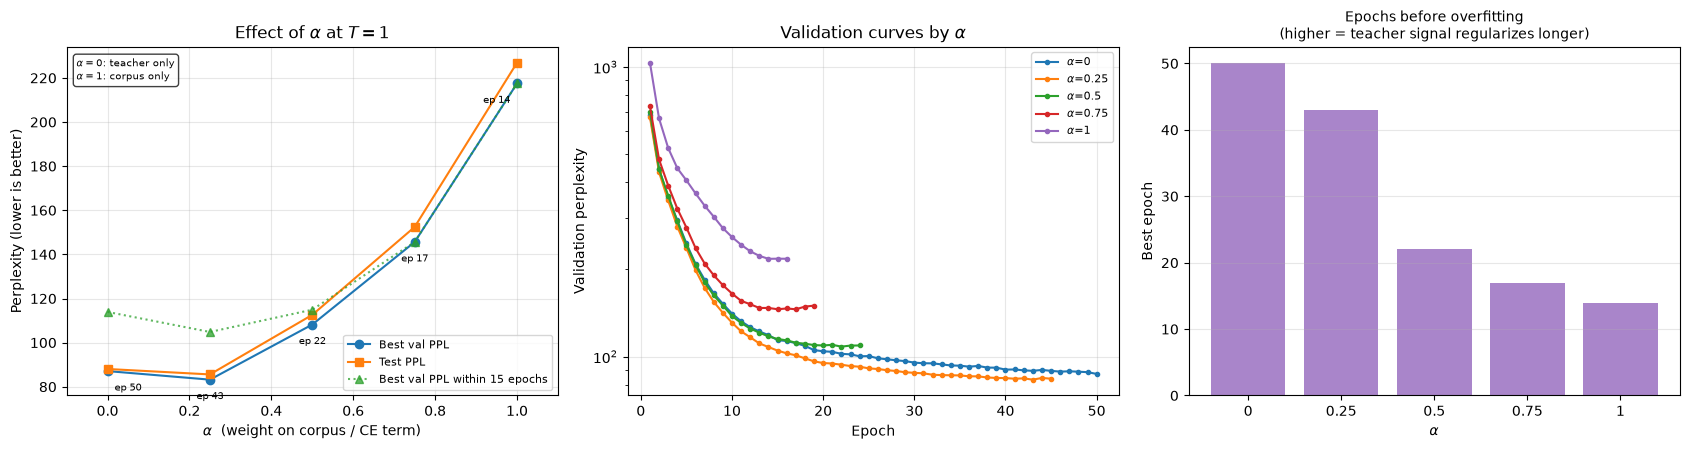

In [3]:
fig = plot_alpha_sweep(grid)
plt.show()

### 11.3 Effect of temperature at $\alpha=0.5$

$T=0.5$ sharpens the teacher distribution (more mass on the top token), $T=2$ softens it.
Unlike the Section 7.3 sweep, these are **fully trained** to early stopping, so the
perplexities are directly comparable to the rest of the results.

The red star marks the gradient-matched $T=0.5$ control from 11.1; it sits almost on top of the
standard $T=0.5$ point, which is what licenses reading the temperature effect directly. The
right-hand panel traces the per-epoch correction $c$ — mostly above 1, contradicting the static
probe's prediction of $c<1$.

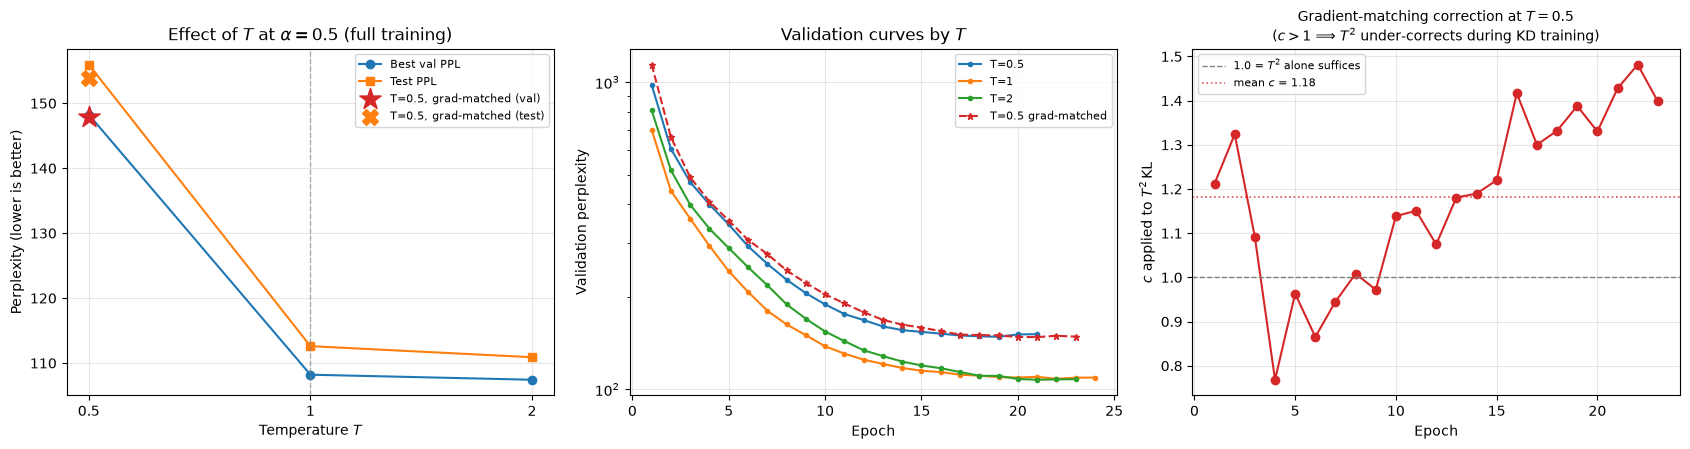

In [6]:
fig = plot_temperature_grid(grid)
plt.show()

### 11.4 Grid summary

The table below is written to `results/grid_summary.csv`. Columns:

- **Best val PPL / Test PPL** -- headline quality, at the restored best-validation checkpoint.
- **Best ep.** -- where early stopping found the optimum; a proxy for how long the objective
  resists overfitting.
- **Val PPL @15ep** -- budget-controlled comparison (see 11.2).
- **Grad-matched** -- whether the KD term was rescaled to match the $T=1$ gradient norm.

In [7]:
table = summary_table(grid)
table.to_csv("results/grid_summary.csv", index=False)
display(table)

print("\nOriginal published run (different machine, kept for reference only):")
for name, vals in PUBLISHED.items():
    ep = f", best epoch {vals['best_epoch']}" if "best_epoch" in vals else ""
    print(f"  {name:<32} val {vals['val_ppl']:>6.1f}  test {vals['test_ppl']:>6.1f}{ep}")


Original published run (different machine, kept for reference only):
  Teacher (GPT-2)                  val   30.6  test   29.4
  Teacher only (alpha=0)           val   89.4  test   90.7, best epoch 39
  Teacher + corpus (alpha=0.5)     val  111.2  test  115.6, best epoch 22
  Corpus only (alpha=1)            val  214.5  test  227.2, best epoch 13


,Tag,Alpha,T,Grad-matched,Best ep.,Epochs run,Best val PPL,Test PPL,Val PPL @15ep,Wall (min)
0,a0.50_T0.5,0.50,0.5,False,19,21,148.26,155.96,153.75,51.08
1,a0.00_T1,0.00,1.0,False,50,50,87.10,88.06,113.92,115.02
2,a0.25_T1,0.25,1.0,False,43,45,83.22,85.59,104.84,109.19
3,a0.50_T1,0.50,1.0,False,22,24,108.21,112.60,114.93,58.31
4,a0.75_T1,0.75,1.0,False,17,19,145.62,152.44,145.66,46.16
5,a1.00_T1,1.00,1.0,False,14,16,217.50,226.90,217.50,16.49
6,a0.50_T2,0.50,2.0,False,21,23,107.43,110.90,119.59,55.77
7,a0.50_T0.5_gm,0.50,0.5,True,21,23,147.89,153.95,158.85,56.02


In [9]:
# Best configuration on each axis, and the verdict on the T^2 confound.
if not grid.empty:
    alpha_axis = grid[(grid.temperature == 1.0) & (~grid.grad_match)]
    temp_axis = grid[(grid.alpha == 0.5) & (~grid.grad_match)]

    if not alpha_axis.empty:
        b = alpha_axis.loc[alpha_axis.test_ppl.idxmin()]
        print(f"Best alpha at T=1: alpha={b.alpha:g} "
              f"(test PPL {b.test_ppl:.2f}, best epoch {b.best_epoch})")
    if not temp_axis.empty:
        b = temp_axis.loc[temp_axis.test_ppl.idxmin()]
        print(f"Best T at alpha=0.5: T={b.temperature:g} "
              f"(test PPL {b.test_ppl:.2f}, best epoch {b.best_epoch})")

    gm = grid[grid.grad_match]
    if not gm.empty:
        plain = grid[(grid.alpha == 0.5) & (grid.temperature == 0.5) & (~grid.grad_match)]
        if not plain.empty:
            g, p = gm.iloc[0], plain.iloc[0]
            t1 = temp_axis[temp_axis.temperature == 1.0]
            print(f"\nT=0.5 standard T^2      : test PPL {p.test_ppl:.2f} (best epoch {p.best_epoch})")
            print(f"T=0.5 gradient-matched  : test PPL {g.test_ppl:.2f} (best epoch {g.best_epoch})")
            gap = p.test_ppl - g.test_ppl
            print(f"  gradient-scale effect : {gap:+.2f} PPL")
            if not t1.empty:
                penalty = p.test_ppl - t1.iloc[0].test_ppl
                print(f"  cost of using T=0.5   : {penalty:+.2f} PPL vs T=1")
                print(f"  => the sharpening penalty is {abs(penalty)/abs(gap):.0f}x the gradient-scale"
                      f" effect, so the T=0.5 result is NOT a gradient-scale artifact.")
            if g.kd_scale_history:
                import numpy as _np
                ks = _np.asarray(g.kd_scale_history)
                print(f"\n  mean per-epoch correction c = {ks.mean():.3f} "
                      f"(range {ks.min():.2f}-{ks.max():.2f}, {100*(ks > 1).mean():.0f}% of epochs > 1)")
                print(f"  c > 1 means the T^2-scaled KD gradient was WEAKER than at T=1 and needed")
                print(f"  boosting -- the opposite of the static CE-trained probe's prediction (c~0.26).")

Best alpha at T=1: alpha=0.25 (test PPL 85.59, best epoch 43)
Best T at alpha=0.5: T=2 (test PPL 110.90, best epoch 21)

T=0.5 standard T^2      : test PPL 155.96 (best epoch 19)
T=0.5 gradient-matched  : test PPL 153.95 (best epoch 21)
  gradient-scale effect : +2.00 PPL
  cost of using T=0.5   : +43.36 PPL vs T=1
  => the sharpening penalty is 22x the gradient-scale effect, so the T=0.5 result is NOT a gradient-scale artifact.

  mean per-epoch correction c = 1.182 (range 0.77-1.48, 78% of epochs > 1)
  c > 1 means the T^2-scaled KD gradient was WEAKER than at T=1 and needed
  boosting -- the opposite of the static CE-trained probe's prediction (c~0.26).
